In [1]:
# TODO: (If Søren says R functionality might become relevant) load models and make predictions in a way where i can easily substitute in non-sklearn models/pipelines

# 1. Loading

## 1.1. Imports and prep

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import joblib
import seaborn as sns
from scipy import stats
from scipy.optimize import curve_fit
import os
import sys
from loguru import logger
from statsmodels.stats.outliers_influence import variance_inflation_factor
import glob
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [3]:
WINDOW_LENGTH = "5min"

In [4]:
notebook_dir = os.getcwd()
notebook_parent_dir = os.path.dirname(notebook_dir)
notebook_parent_parent_dir = os.path.dirname(notebook_parent_dir)
train_test_dir = os.path.join(notebook_parent_parent_dir, "data", "train-and-test")
train_test_split_path = os.path.join(train_test_dir, f"train_test_splits_{WINDOW_LENGTH}.npz")

In [5]:
sys.path.append('..')  # points to the Modelling/ folder

from gam import SklearnGAM

## 1.2. Data

In [6]:
data = np.load(train_test_split_path, allow_pickle=False)
X_train = data['X_train']
X_test  = data['X_test']
y_train = data['y_train']
y_test  = data['y_test']

## 1.3. Models

In [7]:
model_pipelines_incl_foul = {'GAM': None, 'NN': None, 'random_forest': None}

In [8]:
for model in model_pipelines_incl_foul.keys():
    # find the pipeline
    model_pipeline_path = os.path.join(notebook_parent_parent_dir, "outputs", "models", f"{model}_pipeline_incl_fouling_{WINDOW_LENGTH}.joblib")
    model_pipeline = joblib.load(model_pipeline_path)
    
    # add the pipeline to the dict
    model_pipelines_incl_foul[model] = model_pipeline

In [9]:
model_pipelines_excl_foul = {'GAM': None, 'NN': None, 'random_forest': None}

In [10]:
for model in model_pipelines_excl_foul.keys():
    # find the pipeline
    model_pipeline_path = os.path.join(notebook_parent_parent_dir, "outputs", "models", f"{model}_pipeline_excl_fouling_{WINDOW_LENGTH}.joblib")
    model_pipeline = joblib.load(model_pipeline_path)
    
    # add the pipeline to the dict
    model_pipelines_excl_foul[model] = model_pipeline

# 2. Validity & Robustness Checks

## 2.1. GAM-specific

### 2.1.1. Model Summary

In [13]:
# 1. Extract the raw pyGAM model from our fitted pipeline
gam_pipeline = model_pipelines_incl_foul["GAM"]
gam_model = gam_pipeline.named_steps["model"].gam_model_
gam_model.summary()


LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                    181.1056
Link Function:                     IdentityLink Log Likelihood:                               -240343.0266
Number of Samples:                        35880 AIC:                                           481050.2644
                                                AICc:                                          481052.1326
                                                GCV:                                            39079.0039
                                                Scale:                                            196.7844
                                                Pseudo R-Squared:                                   0.9828
Feature Function                  Lam

C:\Users\Augus\AppData\Local\Temp\ipykernel_43388\3057525301.py:4: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  gam_model.summary()


### 2.1.2. Concurvity Check

(not passed yet)

There is no function for concurvity in PyGam, but here 3 different approximations are implemented. The below are numerical approximations, but wide confidence intervals on the partial dependencies is actually the biggest tell

In [16]:
feature_cols = model_pipelines_incl_foul['GAM'].named_steps['preprocessor']\
                                     .transformers_[0][2]

print("Feature columns used in the GAM model:", feature_cols)

Feature columns used in the GAM model: ['Avg Draft (Calculated)', 'Draft Trim (Calculated)', 'cumulative_fouling_penalty_index (calculated)', 'Vessel Hull Through Water Longitudinal Speed (knots)', 'Vessel External Conditions Wind Relative Angle (degrees)', 'Vessel External Conditions Wind Relative Speed (knots)', 'Vessel External Conditions Sea Water Temperature (Provider S)', 'Vessel External Conditions Wave Significant Height (Provider MB)']


In [17]:
X_train_df = pd.DataFrame(X_train, columns=feature_cols)

#### Feature corrrelations

NOTE: this likely under-reports concurvity. Combine with inspection of confidence intervals

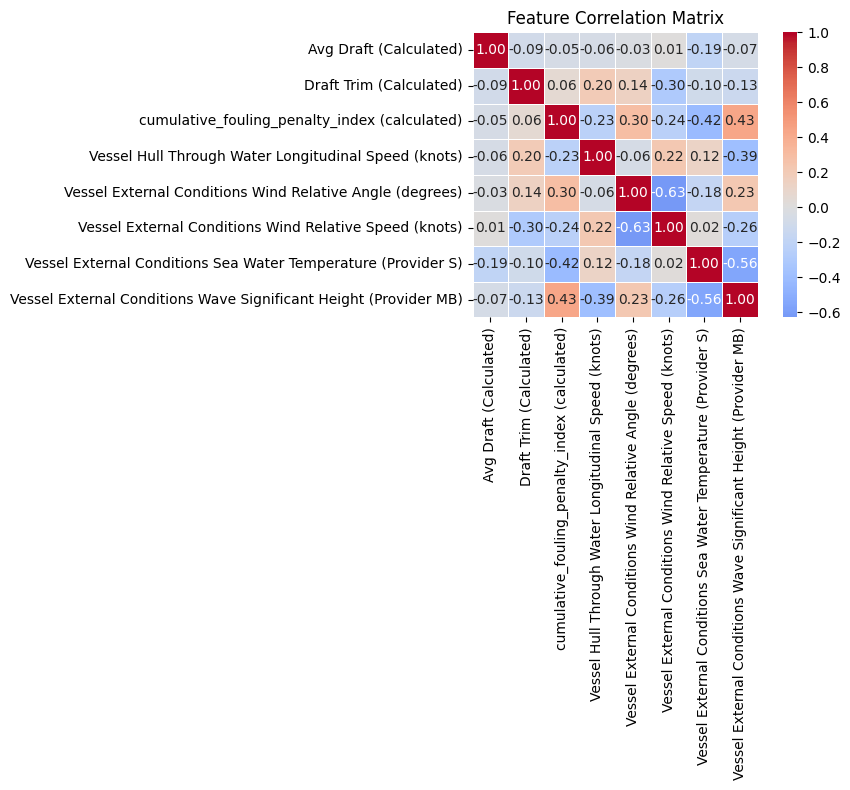

In [18]:
corr_matrix = X_train_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

#### Variance Inflation Factor

NOTE: this likely under-reports concurvity. Combine with inspection of confidence intervals

In [19]:
vif = pd.DataFrame({
    'Feature': feature_cols,
    'VIF': [variance_inflation_factor(X_train_df.values, i) 
            for i in range(X_train_df.shape[1])]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

# Flag problematic features
vif['Status'] = vif['VIF'].apply(lambda x: '⚠️ High' if x > 5 else '✅ OK')
print(vif.to_string(index=False))

                                                         Feature       VIF  Status
Vessel External Conditions Wave Significant Height (Provider MB) 52.154835 ⚠️ High
                   cumulative_fouling_penalty_index (calculated) 40.177184 ⚠️ High
        Vessel External Conditions Wind Relative Angle (degrees) 19.461020 ⚠️ High
            Vessel Hull Through Water Longitudinal Speed (knots)  8.742453 ⚠️ High
                                         Draft Trim (Calculated)  6.215145 ⚠️ High
          Vessel External Conditions Wind Relative Speed (knots)  4.997322    ✅ OK
                                          Avg Draft (Calculated)  2.977107    ✅ OK
   Vessel External Conditions Sea Water Temperature (Provider S)  2.788846    ✅ OK


In [20]:
# To be implemented

#### 

## 2.2. Random-forest specific

### 2.2.1. Feature importance

Fouling proxy should have a decent importance

In [21]:
def plot_rf_feature_importance(pipeline, title="Random Forest Feature Importances", top_n=None):
    """
    Plot feature importances from a fitted RF pipeline.

    Parameters
    ----------
    pipeline : sklearn Pipeline
        Fitted pipeline with 'preprocessor' (ColumnTransformer) and 'model' (RandomForestRegressor) steps.
    title : str
        Plot title.
    top_n : int or None
        If set, only the top_n features by importance are shown.
    """
    feature_names = pipeline.named_steps["preprocessor"].transformers_[0][2]
    importances = pipeline.named_steps["model"].feature_importances_
    std = np.std(
        [tree.feature_importances_ for tree in pipeline.named_steps["model"].estimators_],
        axis=0,
    )

    importance_df = (
        pd.DataFrame({"feature": feature_names, "importance": importances, "std": std})
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    if top_n is not None:
        importance_df = importance_df.head(top_n)

    fig, ax = plt.subplots(figsize=(8, max(4, len(importance_df) * 0.4)))
    ax.barh(
        importance_df["feature"][::-1],
        importance_df["importance"][::-1],
        xerr=importance_df["std"][::-1],
        color="steelblue",
        ecolor="grey",
        capsize=3,
    )
    ax.set_xlabel("Mean decrease in impurity")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

    return importance_df

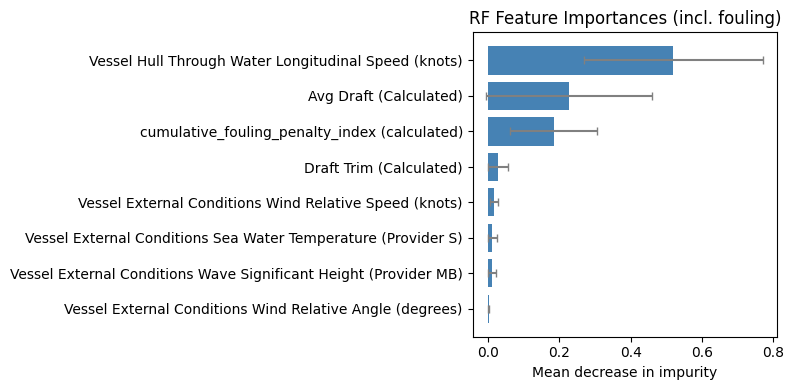

                                                         feature  importance      std
            Vessel Hull Through Water Longitudinal Speed (knots)    0.520238 0.252122
                                          Avg Draft (Calculated)    0.228013 0.232764
                   cumulative_fouling_penalty_index (calculated)    0.183743 0.122801
                                         Draft Trim (Calculated)    0.027417 0.028522
          Vessel External Conditions Wind Relative Speed (knots)    0.016756 0.011580
   Vessel External Conditions Sea Water Temperature (Provider S)    0.011694 0.011843
Vessel External Conditions Wave Significant Height (Provider MB)    0.010059 0.010651
        Vessel External Conditions Wind Relative Angle (degrees)    0.002080 0.001163


In [22]:
importance_df = plot_rf_feature_importance(
    model_pipelines_incl_foul["random_forest"],
    title="RF Feature Importances (incl. fouling)",
)
print(importance_df.to_string(index=False))

## 2.3. NN-specific

## 2.4. All models

### 2.4.1. Incl. vs. excl fouling

#### Performance comparison

#### Residuals comparison

Over time, the residuals for the fouling-free model should have the fouling effect leaking into the error term (residuals increasing over time)

### 2.4.2. Overfitting check

In [31]:
def load_latest_training_results(model_pipelines, outputs_dir):
    """
    For each model in model_pipelines, finds the latest training CSV
    and returns them appended into a single DataFrame.
    """
    dfs = []

    for model in model_pipelines.keys():
        # Find all matching CSVs for this model
        pattern = os.path.join(outputs_dir, f"{model}_training_*.csv")
        files = sorted(glob.glob(pattern))  # alphabetical = chronological for timestamp filenames

        if not files:
            logger.warning(f"No training CSV found for model: {model}")
            continue

        latest_file = files[-1]
        logger.info(f"{model}: loading {os.path.basename(latest_file)}")

        df = pd.read_csv(latest_file)
     #   df.insert(0, "model", model)  # prepend model name for clarity
        dfs.append(df)

    if not dfs:
        raise FileNotFoundError("No training CSV files found for any model.")

    return pd.concat(dfs, ignore_index=True)


In [32]:
outputs_dir = os.path.join(notebook_parent_parent_dir, "outputs", "models")
results_df = load_latest_training_results(model_pipelines_incl_foul, outputs_dir)

# Choose only relevant columns 
results_df = results_df[["model", "train_rmse", "test_rmse", "train_mape", "test_mape"]]

display(results_df.style.format({ "train_rmse": "{:.1f}", "test_rmse": "{:.1f}", "train_mape": "{:.4f}", "test_mape": "{:.4f}" }))

2026-03-10 12:32:25.403 | INFO     | __main__:load_latest_training_results:18 - GAM: loading GAM_training_20260310_105324.csv
2026-03-10 12:32:25.405 | INFO     | __main__:load_latest_training_results:18 - NN: loading NN_training_20260310_105629.csv
2026-03-10 12:32:25.407 | INFO     | __main__:load_latest_training_results:18 - random_forest: loading Random_Forest_training_20260310_122927.csv


,model,train_rmse,test_rmse,train_mape,test_mape
0,GAM_incl_fouling,196.3,205.7,0.0333,0.0345
1,GAM_excl_fouling,486.0,488.8,0.0873,0.0866
2,NN_incl_fouling,123.8,127.5,0.0215,0.0219
3,NN_excl_fouling,145.3,148.7,0.0256,0.0262
4,Random_Forest_incl_fouling,95.8,104.1,0.0149,0.0160
5,Random_Forest_excl_fouling,114.7,120.3,0.0201,0.0209


### 2.4.3. Residual diagnostics

#### Fitted vs. predicted values

In [25]:
# Make two scatterplots side-by-side: one for the actual vs. predicted and one for the residuals vs. predicted. Include red lines representing perfection

#### QQ plot/normality

In [26]:
# Make a QQ-plot for each model

#### Residuals over time

In [27]:
# Plot the residuals over time for each model
# Include a vertical line for cleaning events

#### Residual scatter by each feature 

In [28]:
# Make a function that makes a tight layout with 3 scatterplots in each row

### 2.4.4. Pseudo speed/power curves

# 3. Analysis

## 3.1. GAM - specific

### 3.1.1.  Partial effect of fouling

In [29]:
# Make a conditional wrapper function for two different functions - one which includes the tensor product and one without interactions

### 3.1.2. Partial effect of other features

# 4. Sensitivity Analysis

In [30]:
# Make a function that at least takes the path of controlled variable as input and returns the controlled var dataframe